In [ ]:
! pip install rsatoolbox gwp scikit-image Pillow

## generate stimuli images

genrating the task stimuli for the 12 unimanual conditions

In [9]:
"""
generate_stimuli.py
====================
Generates 12 experimental stimulus images for a visual neuroscience task.

Layout
------
- Black background
- White fixation cross at screen centre
- LEFT side:  one centre circle + 6 surrounding target circles
- RIGHT side: one centre circle + 6 surrounding target circles
- 12 images total: in each image exactly one of the 12 target circles is
  filled white; all others remain empty (outline only)

Target circle indices
---------------------
  0–5  : right side, angles 0°, 60°, 120°, 180°, 240°, 300°
  6–11 : left  side, angles 0°, 60°, 120°, 180°, 240°, 300°

Usage
-----
    python generate_stimuli.py

Output
------
    stimuli/stimulus_01_right_000deg.png
    stimuli/stimulus_02_right_060deg.png
    ...
    stimuli/stimulus_12_left_300deg.png

Requirements
------------
    pip install matplotlib numpy Pillow
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS  ←  edit these to match your display setup
# ─────────────────────────────────────────────────────────────────────────────

IMG_W       = 1024   # image width  (px)
IMG_H       = 768    # image height (px)
DPI         = 96     # dots per inch for saved PNGs

# If you know pixels-per-degree for your monitor:
#   PPD = screen_width_px / (2 * screen_dist_cm * tan(fov_deg/2 * pi/180))
# Set spatial parameters in degrees and multiply by PPD, or leave None.
PPD         = None   # e.g. set to 40 to work in deg

def px(value_px):
    """Scale by PPD if working in degrees, otherwise pass through."""
    return value_px if PPD is None else value_px * PPD

X_OFFSET    = px(180)   # fixation → centre-circle horizontal distance
R_CENTER    = px(18)    # radius of the centre circle
R_TARGETS   = px(75)    # centre-circle → target-circle distance
R_TARGET    = px(14)    # radius of each target circle
CROSS_ARM   = px(16)    # half-length of fixation-cross arms
CROSS_LW    = 2.5       # fixation-cross line width (pt)
CIRCLE_LW   = 1.8       # circle outline line width (pt)

OUTPUT_DIR  = "./stimuli"


# ─────────────────────────────────────────────────────────────────────────────
# GEOMETRY
# ─────────────────────────────────────────────────────────────────────────────

TARGET_ANGLES_DEG = np.arange(0, 360, 60)   # 0, 60, 120, 180, 240, 300

cx, cy = IMG_W / 2, IMG_H / 2               # image / fixation centre

right_cx, right_cy = cx + X_OFFSET, cy
left_cx,  left_cy  = cx - X_OFFSET, cy


def target_positions(side_cx, side_cy):
    """Return (x, y) for 6 target circles around a centre circle."""
    positions = []
    for ang in TARGET_ANGLES_DEG:
        rad = np.radians(ang)
        positions.append((
            side_cx + R_TARGETS * np.cos(rad),
            side_cy + R_TARGETS * np.sin(rad),
        ))
    return positions


right_targets = target_positions(right_cx, right_cy)
left_targets  = target_positions(left_cx,  left_cy)

# Flat list: index 0–5 → right, 6–11 → left
all_targets = (
    [("right", i, x, y) for i, (x, y) in enumerate(right_targets)] +
    [("left",  i, x, y) for i, (x, y) in enumerate(left_targets)]
)


# ─────────────────────────────────────────────────────────────────────────────
# DRAWING
# ─────────────────────────────────────────────────────────────────────────────

def draw_stimulus(filled_idx):
    """
    Return a matplotlib Figure for one stimulus.

    Parameters
    ----------
    filled_idx : int
        Index into all_targets (0–11) of the single filled target circle.
    """
    fig = plt.figure(
        figsize=(IMG_W / DPI, IMG_H / DPI),
        dpi=DPI,
        facecolor="black",
    )
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, IMG_W)
    ax.set_ylim(0, IMG_H)
    ax.set_aspect("equal")
    ax.set_facecolor("black")
    ax.axis("off")

    # Fixation cross
    ax.plot([cx - CROSS_ARM, cx + CROSS_ARM], [cy, cy],
            color="white", lw=CROSS_LW, solid_capstyle="round")
    ax.plot([cx, cx], [cy - CROSS_ARM, cy + CROSS_ARM],
            color="white", lw=CROSS_LW, solid_capstyle="round")

    # Centre circles (both sides, no fill)
    for scx, scy in [(right_cx, right_cy), (left_cx, left_cy)]:
        ax.add_patch(patches.Circle(
            (scx, scy), R_CENTER,
            edgecolor="white", facecolor="none",
            linewidth=CIRCLE_LW,
        ))

    # Target circles
    for idx, (side, angle_i, tx, ty) in enumerate(all_targets):
        filled = (idx == filled_idx)
        ax.add_patch(patches.Circle(
            (tx, ty), R_TARGET,
            edgecolor="white",
            facecolor="white" if filled else "none",
            linewidth=CIRCLE_LW,
        ))

    return fig


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    for idx, (side, angle_i, tx, ty) in enumerate(all_targets):
        angle = TARGET_ANGLES_DEG[angle_i]
        fname = os.path.join(
            OUTPUT_DIR,
            f"stimulus_{idx + 1:02d}_{side}_{angle:03d}deg.png",
        )
        fig = draw_stimulus(idx)
        fig.savefig(fname, dpi=DPI, bbox_inches="tight",
                    pad_inches=0, facecolor="black")
        plt.close(fig)
        print(f"Saved: {fname}")

    print(f"\n  {len(all_targets)} stimulus images saved to '{OUTPUT_DIR}/'")

main()



Saved: ./stimuli/stimulus_01_right_000deg.png
Saved: ./stimuli/stimulus_02_right_060deg.png
Saved: ./stimuli/stimulus_03_right_120deg.png
Saved: ./stimuli/stimulus_04_right_180deg.png
Saved: ./stimuli/stimulus_05_right_240deg.png
Saved: ./stimuli/stimulus_06_right_300deg.png
Saved: ./stimuli/stimulus_07_left_000deg.png
Saved: ./stimuli/stimulus_08_left_060deg.png
Saved: ./stimuli/stimulus_09_left_120deg.png
Saved: ./stimuli/stimulus_10_left_180deg.png
Saved: ./stimuli/stimulus_11_left_240deg.png
Saved: ./stimuli/stimulus_12_left_300deg.png

  12 stimulus images saved to './stimuli/'


## Model the V1 RDM based on these stimuli

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import scipy.ndimage as ndi
from skimage.color import rgb2gray
from skimage.filters import gabor_kernel
import rsatoolbox.data as rsadata
import rsatoolbox.rdm as rsardm
import rsatoolbox.vis as rsavis
import seaborn as sns

# 1. Setup Gabor Filter Bank
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
frequencies = [0.05, 0.1, 0.2] # Adjust depending on spatial details

kernels = []
for theta in orientations:
    for freq in frequencies:
        kernel = gabor_kernel(freq, theta=theta)
        kernels.append(kernel)

# 2. Extract Features
features = []
labels = []

# --- Custom Sorting Logic ---
def custom_sort_key(filename):
    if not filename.endswith('.png'): return (99, 99)
    # Filename format: stimulus_01_right_000deg.png
    parts = filename.replace('.png', '').split('_')
    side = parts[2]
    angle = int(parts[3].replace('deg', ''))
    
    # Rank sides: right first (0), then left (1)
    side_rank = 0 if side == 'right' else 1
    
    # Rank angles exactly as requested: 180, 120, 60, 0, 300, 240
    angle_order = {180: 0, 120: 1, 60: 2, 0: 3, 300: 4, 240: 5}
    angle_rank = angle_order.get(angle, 99)
    
    return (side_rank, angle_rank)

image_names = sorted(os.listdir(OUTPUT_DIR), key=custom_sort_key)

for img_name in image_names:
    if not img_name.endswith('.png'):
        continue
    img_path = os.path.join(OUTPUT_DIR, img_name)
    
    # Read, convert to grayscale and normalize
    img = Image.open(img_path).convert('RGB')
    img_gray = rgb2gray(np.array(img))
    
    # Downsample image first to speed up convolution
    img_gray = img_gray[::4, ::4]
    
    img_features = []
    # Convolve with each kernel, calculate energy
    for kernel in kernels:
        res_real = ndi.convolve(img_gray, np.real(kernel), mode='wrap')
        res_imag = ndi.convolve(img_gray, np.imag(kernel), mode='wrap')
        energy = np.sqrt(res_real**2 + res_imag**2)
        
        # Downsample to simulate pooling and reduce dims
        # Using block_reduce or simply slicing
        energy_pooled = energy[::4, ::4]
        img_features.extend(energy_pooled.ravel())
        
    features.append(img_features)
    labels.append(img_name.replace('.png', ''))

features = np.array(features)

# 3. Calculate V1 RDM
dataset = rsadata.Dataset(
    measurements=features,
    descriptors={'session': 'V1_simulation'},
    obs_descriptors={'conds': labels}
)

calc_rdm = rsardm.calc_rdm(dataset, method='euclidean')

# 4. Save variables to ./rdm_output
os.makedirs('./rdm_output', exist_ok=True)
dataset.save('./rdm_output/v1_dataset.hdf5', file_type='hdf5', overwrite=True)
calc_rdm.save('./rdm_output/v1_rdm.hdf5', file_type='hdf5', overwrite=True)



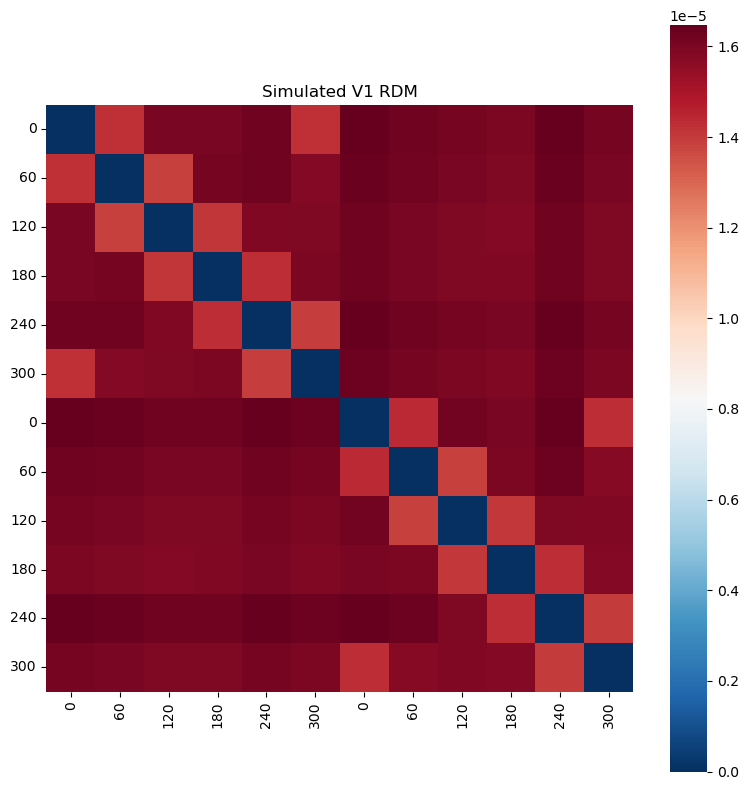

In [35]:
# labels = ['0','60','120','180','240','300', '0','60','120','180','240','300']

# get the RDM matrix as a numpy array
rdm_matrix = calc_rdm.get_matrices()[0]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.heatmap(rdm_matrix, cmap='RdBu_r', square=True, ax=ax)
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels, rotation=0)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title("Simulated V1 RDM")
plt.tight_layout()
plt.show()



## simulate with eccentricity

<Figure size 800x800 with 0 Axes>

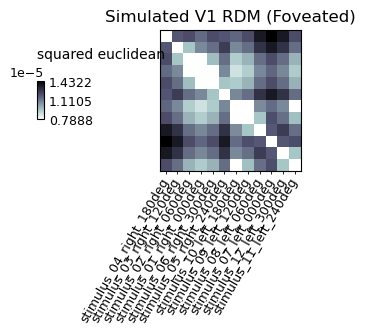

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import scipy.ndimage as ndi
from skimage.color import rgb2gray
from skimage.filters import gabor_kernel
import rsatoolbox.data as rsadata
import rsatoolbox.rdm as rsardm
import rsatoolbox.vis as rsavis

# Image center (Fixation point based on previous generator cell)
cx, cy = 1024 / 2, 768 / 2  
OUTPUT_DIR = "./stimuli"

# 1. Setup Gabor Filter Bank
orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
frequencies = [0.05, 0.1, 0.2]

kernels = []
for theta in orientations:
    for freq in frequencies:
        kernel = gabor_kernel(freq, theta=theta)
        kernels.append(kernel)

def apply_foveation(img_gray, cx, cy):
    """
    Simulates cortical magnification (foveation effect) by progressively 
    blurring the image as eccentricity increases. This biologically mimics 
    receptive fields becoming larger and losing high-frequency resolution 
    in the periphery.
    """
    y, x = np.indices(img_gray.shape)
    eccentricity_px = np.sqrt((x - cx)**2 + (y - cy)**2)
    
    # Biologically feasible parameters for visual acuity drop-off
    # We define progressive blur levels (sigmas)
    sigmas = [0, 2, 4, 8, 16]
    blurred_images = [ndi.gaussian_filter(img_gray, sigma=s) for s in sigmas]
    
    foveated_img = np.zeros_like(img_gray)
    # The blur target increases linearly with eccentricity 
    # e.g., sigma increases by 1 for every 40 pixels away from the fovea
    sigma_target = eccentricity_px * 0.025 
    
    for i in range(len(sigmas) - 1):
        s1, s2 = sigmas[i], sigmas[i+1]
        img1, img2 = blurred_images[i], blurred_images[i+1]
        
        # Blend based on eccentricity distance
        w2 = np.clip((sigma_target - s1) / (s2 - s1), 0, 1)
        w1 = 1.0 - w2
        
        mask = (sigma_target >= s1) & (sigma_target < s2)
        foveated_img[mask] = (img1 * w1 + img2 * w2)[mask]
        
    # Cap at the maximum blur for the far periphery
    foveated_img[sigma_target >= sigmas[-1]] = blurred_images[-1][sigma_target >= sigmas[-1]]
    
    return foveated_img

# 2. Extract Features with Eccentricity Effect
features_fov = []
labels = []

# --- Custom Sorting Logic ---
def custom_sort_key(filename):
    if not filename.endswith('.png'): return (99, 99)
    # Filename format: stimulus_01_right_000deg.png
    parts = filename.replace('.png', '').split('_')
    side = parts[2]
    angle = int(parts[3].replace('deg', ''))
    
    # Rank sides: right first (0), then left (1)
    side_rank = 0 if side == 'right' else 1
    
    # Rank angles exactly as requested: 180, 120, 60, 0, 300, 240
    angle_order = {180: 0, 120: 1, 60: 2, 0: 3, 300: 4, 240: 5}
    angle_rank = angle_order.get(angle, 99)
    
    return (side_rank, angle_rank)

# Sort the images based on the custom key
image_names = sorted(os.listdir(OUTPUT_DIR), key=custom_sort_key)

for img_name in image_names:
    if not img_name.endswith('.png'): continue
    img_path = os.path.join(OUTPUT_DIR, img_name)
    
    img = Image.open(img_path).convert('RGB')
    img_gray = rgb2gray(np.array(img))
    
    # Apply foveation prior to V1 filter sampling
    img_gray_fov = apply_foveation(img_gray, cx, cy)
    
    # Downsample to speed up convolution
    img_gray_fov = img_gray_fov[::4, ::4]
    
    img_features = []
    # Convolve with each kernel, calculate energy
    for kernel in kernels:
        res_real = ndi.convolve(img_gray_fov, np.real(kernel), mode='wrap')
        res_imag = ndi.convolve(img_gray_fov, np.imag(kernel), mode='wrap')
        energy = np.sqrt(res_real**2 + res_imag**2)
        
        # Downsample to simulate pooling
        energy_pooled = energy[::4, ::4]
        img_features.extend(energy_pooled.ravel())
        
    features_fov.append(img_features)
    labels.append(img_name.replace('.png', ''))

features_fov = np.array(features_fov)

# 3. Calculate V1 RDM
dataset_fov = rsadata.Dataset(
    measurements=features_fov,
    descriptors={'session': 'V1_simulation_foveated'},
    obs_descriptors={'conds': labels}
)

calc_rdm_fov = rsardm.calc_rdm(dataset_fov, method='euclidean')

# 4. Save variables to ./rdm_output
os.makedirs('./rdm_output', exist_ok=True)
# rsatoolbox built-in saving 
dataset_fov.save('./rdm_output/v1_foveated_dataset.hdf5', file_type='hdf5', overwrite=True)
calc_rdm_fov.save('./rdm_output/v1_foveated_rdm.hdf5', file_type='hdf5', overwrite=True)

# 5. Visualize
plt.figure(figsize=(8, 8))
rsavis.show_rdm(calc_rdm_fov, rdm_descriptor='conds', pattern_descriptor='conds', show_colorbar='figure')
plt.title("Simulated V1 RDM (Foveated)")
plt.show()




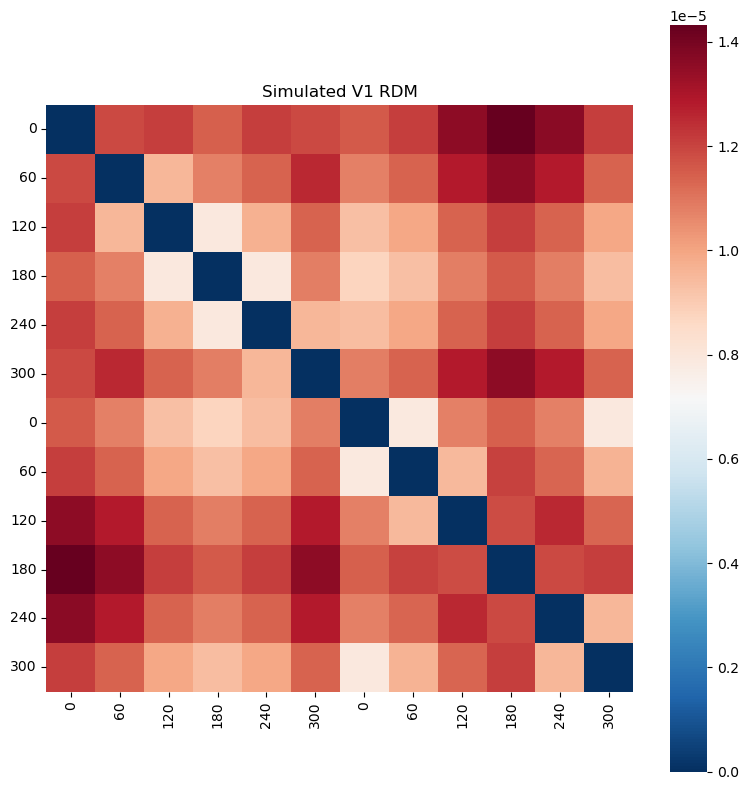

In [37]:
# load rdm:
calc_rdm_fov = rsardm.load_rdm('./rdm_output/v1_foveated_rdm.hdf5')

# get the RDM matrix as a numpy array
rdm_matrix = calc_rdm_fov.get_matrices()[0]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.heatmap(rdm_matrix, cmap='RdBu_r', square=True, ax=ax)
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels, rotation=0)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title("Simulated V1 RDM")
plt.tight_layout()
plt.show()